                        TASK-1

Problem 1

In [73]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [74]:
print(tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [75]:
import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

GPU is not detected so i will still explain why CPU is slower than GPU as it has very fewer cores than GPU and as CPU is optimised for sequential processing but on the other hand GPU is optimised on parallel computation.               On GPU the different ways we use are-using larger batch size due to its capacity to process bigger data                                               -training more complex data                        -using more epochs in lesser duration.             We are setting random seeds to ensure rperoducibility as if we use without seeds every run will give different results so to get same output every time we use seeds.                  ALL seeds controls different randomness astf.random.set_seed(42) tenflow (trains model) and controls neural network operations ,np.random.seed(42) controls numpy array operations,rnamdom seeds(42) control python randomm functions.

Problem 2

In [76]:
from tensorflow.keras.datasets import mnist, cifar10

(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()

In [77]:
print("MNIST Training Shape:", x_train_mnist.shape)
print("MNIST Test Shape:", x_test_mnist.shape)

print("CIFAR-10 Training Shape:", x_train_cifar.shape)
print("CIFAR-10 Test Shape:", x_test_cifar.shape)

MNIST Training Shape: (60000, 28, 28)
MNIST Test Shape: (10000, 28, 28)
CIFAR-10 Training Shape: (50000, 32, 32, 3)
CIFAR-10 Test Shape: (10000, 32, 32, 3)


In [78]:
print("\nMNIST Data Type:", x_train_mnist.dtype)
print("MNIST Pixel Range:", x_train_mnist.min(), "to", x_train_mnist.max())

print("\nCIFAR-10 Data Type:", x_train_cifar.dtype)
print("CIFAR-10 Pixel Range:", x_train_cifar.min(), "to", x_train_cifar.max())


MNIST Data Type: uint8
MNIST Pixel Range: 0 to 255

CIFAR-10 Data Type: uint8
CIFAR-10 Pixel Range: 0 to 255


In [79]:
unique, counts = np.unique(y_train_mnist, return_counts=True)

print("\nMNIST Class Distribution:")
for i in range(len(unique)):
    print("Digit", unique[i], ":", counts[i], "samples")


MNIST Class Distribution:
Digit 0 : 5923 samples
Digit 1 : 6742 samples
Digit 2 : 5958 samples
Digit 3 : 6131 samples
Digit 4 : 5842 samples
Digit 5 : 5421 samples
Digit 6 : 5918 samples
Digit 7 : 6265 samples
Digit 8 : 5851 samples
Digit 9 : 5949 samples


(a) Shape of dataset=
MNIST training shape= (60000, 28, 28)
MNIST test shape= (10000, 28, 28)
CIFAR-10 training shape= (50000, 32, 32, 3)
CIFAR-10 test shape= (10000, 32, 32, 3)            (b) Data types and pixel range=
Data types of image(MNIST and CIFAR-10)= uint8
Pixel values range from= 0 to 255 For both MNIST and CIFAR-10                                       (c) Class distributions in MNIST=
Each digit (0–9) has approximately 6000 samples
So,we can say that the dataset is balanced because all classes have almost similar number of samples.

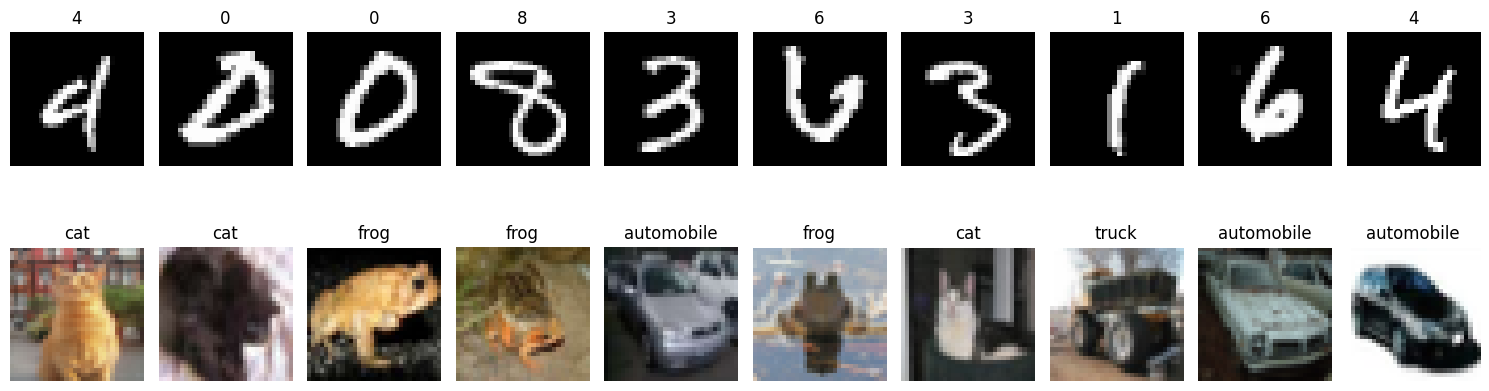

In [8]:
import matplotlib.pyplot as plt
import numpy as np


cifar_classes = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

plt.figure(figsize=(15,5))

mnist_indices = np.random.choice(len(x_train_mnist), 10)

for i, idx in enumerate(mnist_indices):
    plt.subplot(2, 10, i+1)
    plt.imshow(x_train_mnist[idx], cmap='gray')
    plt.title(y_train_mnist[idx])
    plt.axis('off')


cifar_indices = np.random.choice(len(x_train_cifar), 10)

for i, idx in enumerate(cifar_indices):
    plt.subplot(2, 10, i+11)
    plt.imshow(x_train_cifar[idx])
    plt.title(cifar_classes[y_train_cifar[idx][0]])
    plt.axis('off')


plt.tight_layout()

plt.show()

Problem 3

Normalisation

In [9]:
x_train_mnist = x_train_mnist.astype('float32') / 255.0

In [10]:
print("After normalization:")
print("Data type:", x_train_mnist.dtype)
print("Range:", x_train_mnist.min(), "to", x_train_mnist.max())

After normalization:
Data type: float32
Range: 0.0 to 1.0


Reshape

In [11]:
x_train_mnist = x_train_mnist.reshape(-1,28,28,1)

In [12]:
print("\nAfter reshaping:")
print("Shape:", x_train_mnist.shape)


After reshaping:
Shape: (60000, 28, 28, 1)


one-hot

In [13]:
y_onehot = np.zeros((len(y_train_mnist),10))
for i in range(len(y_train_mnist)):
    y_onehot[i, y_train_mnist[i]] = 1

In [14]:
print("\nAfter one-hot encoding:")
print("Shape:", y_onehot.shape)
print("Sample:\n", y_onehot[:5])


After one-hot encoding:
Shape: (60000, 10)
Sample:
 [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


Problem4

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

In [16]:
indices = np.random.choice(len(x_train_cifar), 5)
sample_images = x_train_cifar[indices]

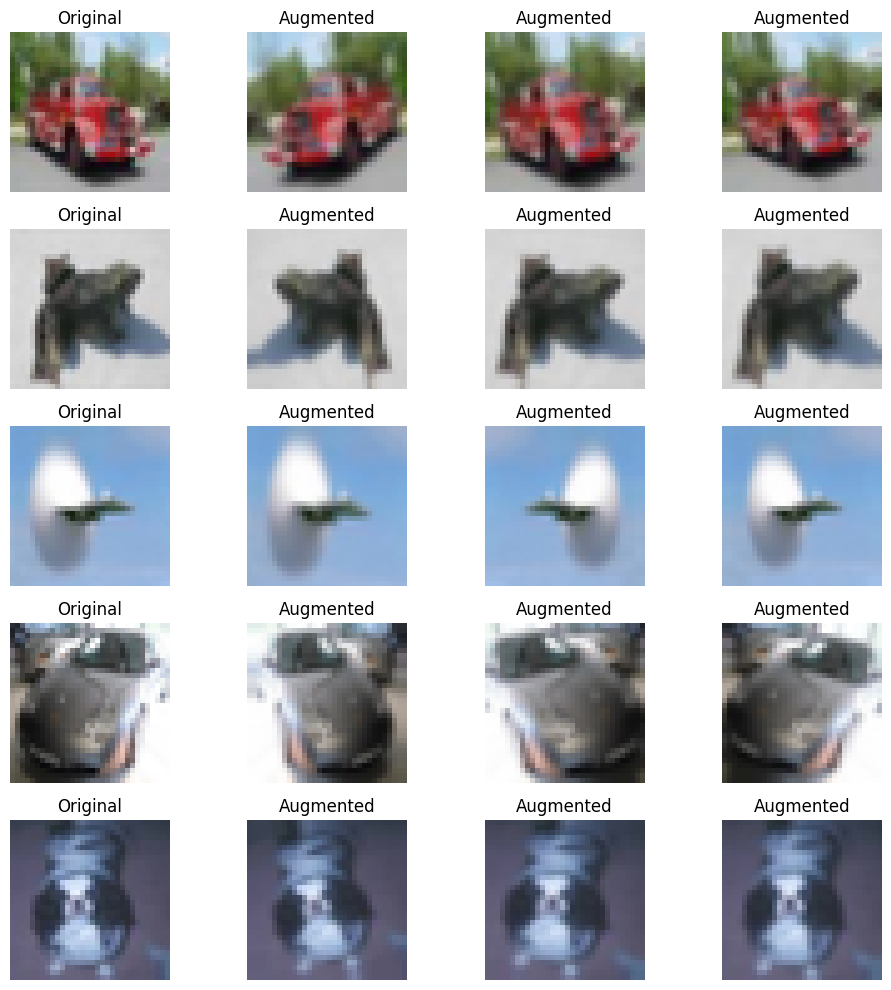

In [17]:
plt.figure(figsize=(10,10))

for i in range(5):

    plt.subplot(5, 4, i*4 + 1)
    plt.imshow(sample_images[i])
    plt.title("Original")
    plt.axis('off')

    img = sample_images[i].reshape((1,32,32,3))

    aug_iter = datagen.flow(img, batch_size=1)

    for j in range(3):
        aug_img = next(aug_iter)[0].astype('uint8')

        plt.subplot(5, 4, i*4 + 2 + j)
        plt.imshow(aug_img)
        plt.title("Augmented")
        plt.axis('off')

plt.tight_layout()

plt.show()

Augmenation only works for training dataset because as it helps the model to learn better by increasing the diversity of data and reducing its overfitting.The test set must not change so it can represent real-world data and do the fair evaluation of model's performance.Due to applying augmentaion it can give misleading results and make performance evalution incorrect.

ANALYTICAL QUESTIONS

Q1. Compare the parameter efficiency of two stacked 3×3 Conv layers versus one 5×5 Conv layer on the same input with the same number of filters. Which uses fewer parameters? Show numerical proof and explain any other advantages of the smaller kernel approach.                                  ANS.One 5×5 Convo Layer

Parameter formula:
Params=(5X5XC+1)XF                               Two 3×3 Conv Layers
First layer:(3×3×C+1)×F=(9C+1)F
Second layer:

Input channels = F
(3×3×F+1)×F=(9F+1)F                               Total parameters:
(9C+1)F+(9F+1)F                                    Although two 3×3 layers have more parameters than one 5×5 layer but Two 3×3 layers give Same receptive field (5×5)But more non-linearity.      numeerical-Let,

C = 3 (RGB image)
F = 64 filters                                    for 5×5 layer,(25×3+1)×64=(75+1)×64=76×64=4864
for two 3x3 layer,(9×3+1)×64=(27+1)×64=28×64=1792  (9×3+1)×64=(27+1)×64=28×64=1792,1792+36928=38720

Q2. What is the role of Batch Normalisation in a CNN? Where in the layer stack should it be placed (before or
after activation), and why? Mention at least two empirical benefits it provides during training.                                        ANS.Batch normalisation is used to normalize the output of a layer so that it has(mean ≈ 0,variance ≈ 1).This makes training more stable and faster.   Batch norm is placed before activation,placing it before activation function gives better and more stable results.it has higher learning rate and it act as regulisation.

Q3. Your custom CNN has a GlobalAveragePooling layer before the Dense head. What does this layer do
geometrically? What would happen to the parameter count and spatial information if you replaced it with
Flatten?                                        ANS.GAP layer takes each feature map and computes the average of all the values of the map.Parameter Count with GAP is very few parameters as Output size is equal to C but for Flatten Output size is H × W × C which is much bigger input to Dense layer and creates large increase in parameters.


                                       TASK-2

Problem 1

In [18]:
def conv2d(image, kernel, stride=1, padding=0):

    H, W = image.shape
    kH, kW = kernel.shape

    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')


    H_p, W_p = image.shape

    out_H = (H_p - kH) // stride + 1
    out_W = (W_p - kW) // stride + 1


    output = np.zeros((out_H, out_W))


    for i in range(out_H):
        for j in range(out_W):


            patch = image[i*stride:i*stride+kH, j*stride:j*stride+kW]


            output[i, j] = np.sum(patch * kernel)

    return output



In [19]:
image = np.array([
    [3,1,0,2,4],[1,5,3,2,1],[0,2,6,4,3],[2,3,1,5,2],[1,0,2,3,4]
])

In [20]:
kernel = np.array([
    [-1,0,1],[-2,0,2], [-1,0,1]
])

In [21]:
output = conv2d(image, kernel, stride=1, padding=0)

print("Output Feature Map:\n", output)
print("Output Shape:", output.shape)

Output Feature Map:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output Shape: (3, 3)


Problem 2

Output=[(Input−Kernel+2×Padding)/stride​]+1       a)[(28−5+0)/1]​+1=23+1=24 ,ans is 24x24                                             b)[(28−3+2)/1]​+1=27+1=28  ,ans is 28x28                                             c)[(32−3+0)/2]​+1=29/2​+1=15.5 so value is 15x15                                             d)First Layer,

Input = 32
K = 3, P = 1, S = 1
[(32−3+2)/1]=31+1=32                             Second Layer,

Input = 32
K = 3, P = 0, S = 1
[(32−3+0)/1]=29+1=30
	​
ans is 30x30


Problem 3

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Dense, Flatten

model = Sequential()

model.add(Conv2D(6, (5,5), activation='tanh', padding='valid', input_shape=(28,28,1)))
model.add(AveragePooling2D(pool_size=(2,2), strides=2))

model.add(Conv2D(16, (5,5), activation='tanh', padding='valid'))
model.add(AveragePooling2D(pool_size=(2,2), strides=2))

model.add(Flatten())
model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

(b) Manual Parameter Calculation (First Conv Layer)=                              Params=(K×K×C+1)×C
out
	​


For first layer:

K = 5
C_in = 1 (grayscale MNIST)
C_out = 6

=(5×5×1+1)×6

=(25+1)×6=26×6=156                                                           (c) Why AvgPooling in LeNet-5 vs MaxPooling today?                           ANS.In LeNet-5, Average Pooling was used because early CNNs focused on smoothing features and reducing sensitivity to noise by averaging values in a region. But modern CNNs prefer MaxPooling because it selects the strongest activation, which helps preserve important features like edges and textures. MaxPooling also works better with ReLU activations and improves performance in deep networks.                                                               

Problem 4

a)Input (32×32×3)

↓ Conv Block 1
Conv2D(32) → BatchNorm → ReLU → MaxPool

↓ Conv Block 2
Conv2D(64) → BatchNorm → ReLU → MaxPool

↓ Conv Block 3
Conv2D(128) → BatchNorm → ReLU → MaxPool

↓ GlobalAveragePooling

↓ Dense(128) → ReLU

↓ Dropout(0.5)

↓ Dense(10) → Softmax (Output)                                                  b)This model uses three convolutional blocks to progressively extract features from low-level edges to high-level patterns. Batch Normalisation is applied after each convolution to stabilize training and improve convergence. MaxPooling is used to reduce spatial dimensions and control overfitting. GlobalAveragePooling9GAP) reduces the number of parameters before the Dense layers, and Dropout is added to prevent overfitting. The architecture balances complexity and efficiency to perform well on CIFAR-1.                     

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()


model.add(Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))


model.add(Conv2D(64, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(GlobalAveragePooling2D())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

Now the expected parameter count is ~300K – 600K which is in the expected range of (200K–2M).

ANALYTICAL QUESTIONS

Q1. Compare the parameter efficiency of two stacked 3×3 Conv layers versus one 5×5 Conv layer on the
same input with the same number of filters. Which uses fewer parameters? Show numerical proof and
explain any other advantages of the smaller kernel approach?                 ANS.On comparing One 5×5 Conv layer and two stacked 3×3 Conv layers Input ,we will assume channels = C and Number of filters = F                           for One 5×5 Convolution Layer Params=(5×5×C+1)×F=(25C+1)F                    for two 3×3 Convolution Layers
First layer:
(3×3×C+1)×F=(9C+1)F
Second layer:
(3×3×F+1)×F=(9F+1)F
Total:(9C+1)F+(9F+1)F                                                         ex.C=3,F=64                                                                    for 5×5 Conv:(25×3+1)×64=(75+1)×64=76×64=4864                                   for two 3×3 Conv:
First layer:(9×3+1)×64=28×64=1792
Second layer:(9×64+1)×64=577×64=36928
Total:1792+36928=38720                                                          Although two stacked 3×3 convolution layers may use more parameters when the number of filters is the same, they are preferred because they provide the same receptive field as a 5×5 layer while introducing additional non-linearity and improving feature learning.

Q2. What is the role of Batch Normalisation in a CNN? Where in the layer stack should it be placed (before or
after activation), and why? Mention at least two empirical benefits it provides during training?                                                                ANS.Batch Normalisation is used to normalize the output of a layer so that the
mean ≈ 0 and Variance ≈ 1.This helps make training faster and more stable.it is placd before activation function to improve learning and stability.             Its two empirical benefits are 1) Faster Convergence in which model trains faster and requires fewer epochs.                                               2)it allows higher Learning Rate.     

Q3. Your custom CNN has a GlobalAveragePooling layer before the Dense head. What does this layer do
geometrically? What would happen to the parameter count and spatial information  if you replaced it with
Flatten?                                                                     ANS.GlobalAveragePooling (GAP) layer takes each feature map and computes the average of all the values in it.If it is replaced with flatten then there will be huge increase in parameters and GAP loses spatial information (position of features)and keeps overall presence of features while Flatten preserves spatial arrangement keeps detailed structure of features.

                                                    TASK-3

Problem 1

In [24]:
(x_train_mnist, y_train_mnist), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


x_train_mnist = x_train_mnist.reshape(-1, 28, 28, 1) / 255.0

y_onehot = tf.keras.utils.to_categorical(y_train_mnist, 10)


model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    x_train_mnist, y_onehot,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9516 - loss: 0.1623 - val_accuracy: 0.9828 - val_loss: 0.0597
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9852 - loss: 0.0479 - val_accuracy: 0.9825 - val_loss: 0.0638
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9900 - loss: 0.0315 - val_accuracy: 0.9857 - val_loss: 0.0558
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9930 - loss: 0.0223 - val_accuracy: 0.9857 - val_loss: 0.0540
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9946 - loss: 0.0169 - val_accuracy: 0.9882 - val_loss: 0.0458
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9955 - loss: 0.0137 - val_accuracy: 0.9892 - val_loss: 0.0447
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9967 - loss: 0.0100 - val_accuracy: 0.9892 - val_loss: 0.0499
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9971 - loss: 0.0090 - val_accuracy: 0

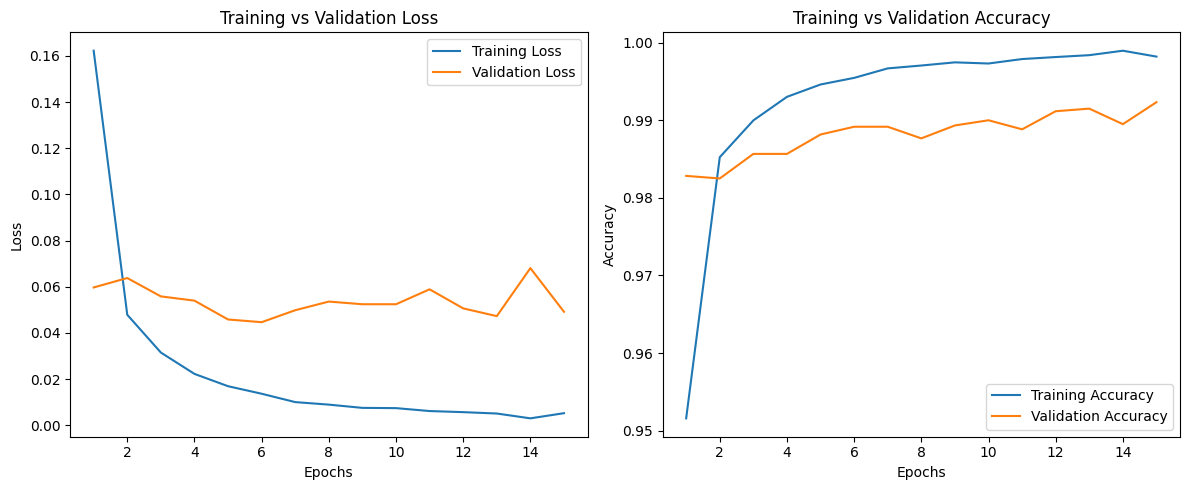

In [25]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, train_acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()


plt.tight_layout()
plt.savefig('lenet_sgd_curves.png')

plt.show()

In [26]:
overfit_epoch = None

for i in range(1, len(val_loss)):
    if val_loss[i] > val_loss[i-1]:
        overfit_epoch = i + 1
        break

if overfit_epoch:
    print(f"Overfitting starts at epoch: {overfit_epoch}")
else:
    print("No clear overfitting observed")

Overfitting starts at epoch: 2


In [27]:

x_test = x_test.reshape(-1, 28, 28, 1) / 255.0
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)


test_loss, test_acc = model.evaluate(x_test, y_test_onehot)

print(f"Final Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9919 - loss: 0.0394
Final Test Accuracy: 0.9919


Problem 2

In [28]:
def create_lenet():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1)),
        tf.keras.layers.AveragePooling2D(),

        tf.keras.layers.Conv2D(16, (5,5), activation='tanh'),
        tf.keras.layers.AveragePooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(120, activation='tanh'),
        tf.keras.layers.Dense(84, activation='tanh'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

In [29]:
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()

x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
y_train = tf.keras.utils.to_categorical(y_train, 10)

In [30]:
def create_lenet():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1)),
        tf.keras.layers.AveragePooling2D(pool_size=(2,2)),

        tf.keras.layers.Conv2D(16, (5,5), activation='tanh'),
        tf.keras.layers.AveragePooling2D(pool_size=(2,2)),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(120, activation='tanh'),
        tf.keras.layers.Dense(84, activation='tanh'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

In [31]:
histories = {}


model_sgd = create_lenet()
model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

histories['SGD'] = model_sgd.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)


model_momentum = create_lenet()
model_momentum.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

histories['SGD + Momentum'] = model_momentum.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)


model_adam = create_lenet()
model_adam.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

histories['Adam'] = model_adam.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7839 - loss: 0.8995 - val_accuracy: 0.9055 - val_loss: 0.3849
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8932 - loss: 0.3884 - val_accuracy: 0.9285 - val_loss: 0.2769
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9116 - loss: 0.3100 - val_accuracy: 0.9378 - val_loss: 0.2296
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9236 - loss: 0.2647 - val_accuracy: 0.9455 - val_loss: 0.1979
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9322 - loss: 0.2310 - val_accuracy: 0.9513 - val_loss: 0.1737
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9401 - loss: 0.2041 - val_accuracy: 0.9563 - val_loss: 0.1543
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9467 - loss: 0.1819 - val_accuracy: 0.9613 - val_loss: 0.1385
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9517 - loss: 0.1634 - val_accuracy: 0.

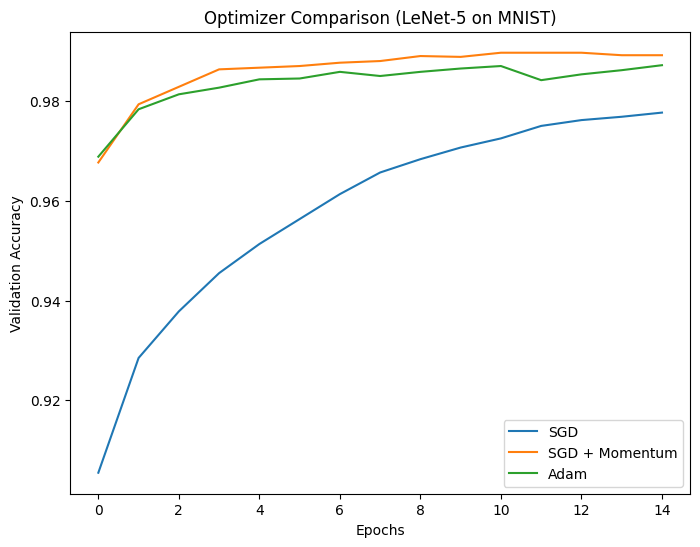

In [32]:
plt.figure(figsize=(8,6))

for name, history in histories.items():
    val_acc = history.history['val_accuracy']
    plt.plot(val_acc, label=name)

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Optimizer Comparison (LeNet-5 on MNIST)')
plt.legend()

plt.show()

Problem 3

In [33]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [34]:

x_train = x_train.astype('float32') / 255.0

y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout

def build_model(lr):
    model = Sequential()

    model.add(Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D())

    model.add(Conv2D(64, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D())

    model.add(Conv2D(128, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D())

    model.add(GlobalAveragePooling2D())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [36]:
learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]

results = np.zeros((3,2))  # 3x2 table

In [37]:
for i, lr in enumerate(learning_rates):
    for j, bs in enumerate(batch_sizes):

        print(f"\nTraining with LR={lr}, Batch Size={bs}")

        model = build_model(lr)

        history = model.fit(
            x_train, y_train_onehot,
            epochs=10,
            batch_size=bs,
            validation_split=0.1,
            verbose=0
        )

        final_val_acc = history.history['val_accuracy'][-1]
        results[i, j] = final_val_acc

        print(f"Final Val Accuracy: {final_val_acc:.4f}")


Training with LR=0.1, Batch Size=32
Final Val Accuracy: 0.7156

Training with LR=0.1, Batch Size=128
Final Val Accuracy: 0.6092

Training with LR=0.01, Batch Size=32
Final Val Accuracy: 0.5046

Training with LR=0.01, Batch Size=128
Final Val Accuracy: 0.5362

Training with LR=0.001, Batch Size=32
Final Val Accuracy: 0.2824

Training with LR=0.001, Batch Size=128
Final Val Accuracy: 0.4206


In [38]:
print("\nValidation Accuracy Table (rows=LR, cols=Batch Size):\n")
print("        BS=32     BS=128")

for i, lr in enumerate(learning_rates):
    print(f"LR={lr:<6} {results[i,0]:.4f}   {results[i,1]:.4f}")


Validation Accuracy Table (rows=LR, cols=Batch Size):

        BS=32     BS=128
LR=0.1    0.7156   0.6092
LR=0.01   0.5046   0.5362
LR=0.001  0.2824   0.4206


Problem 4

In [39]:
def create_model(use_dropout=False, use_bn=False):
    model = tf.keras.models.Sequential()


    model.add(tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
    if use_bn:
        model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.MaxPooling2D((2,2)))
    if use_dropout:
        model.add(tf.keras.layers.Dropout(0.3))

    model.add(tf.keras.layers.Conv2D(64, (3,3), activation='relu'))
    if use_bn:
        model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.MaxPooling2D((2,2)))
    if use_dropout:
        model.add(tf.keras.layers.Dropout(0.3))


    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(128, activation='relu'))
    if use_dropout:
        model.add(tf.keras.layers.Dropout(0.5))

    model.add(tf.keras.layers.Dense(10, activation='softmax'))

    return model

In [40]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), _ = cifar10.load_data()

x_train = x_train / 255.0
y_train = tf.keras.utils.to_categorical(y_train, 10)

In [41]:
configs = {
    "No Reg": (False, False),
    "Dropout Only": (True, False),
    "BatchNorm Only": (False, True),
    "Dropout + BatchNorm": (True, True)
}

histories = {}
gaps = {}

for name, (use_dropout, use_bn) in configs.items():
    print(f"\nTraining: {name}")

    model = create_model(use_dropout, use_bn)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train, y_train,
        epochs=20,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )

    histories[name] = history


    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    gaps[name] = train_acc - val_acc


Training: No Reg
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.4563 - loss: 1.5090 - val_accuracy: 0.5436 - val_loss: 1.2823
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5964 - loss: 1.1499 - val_accuracy: 0.6292 - val_loss: 1.0729
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6517 - loss: 1.0080 - val_accuracy: 0.6564 - val_loss: 0.9886
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6815 - loss: 0.9169 - val_accuracy: 0.6772 - val_loss: 0.9441
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7085 - loss: 0.8436 - val_accuracy: 0.6902 - val_loss: 0.9177
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7312 - loss: 0.7732 - val_accuracy: 0.6974 - val_loss: 0.8975
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7506 - loss: 0.7158 - val_accuracy: 0.6922 - val_loss: 0.9053
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7704 - loss: 0.6638 

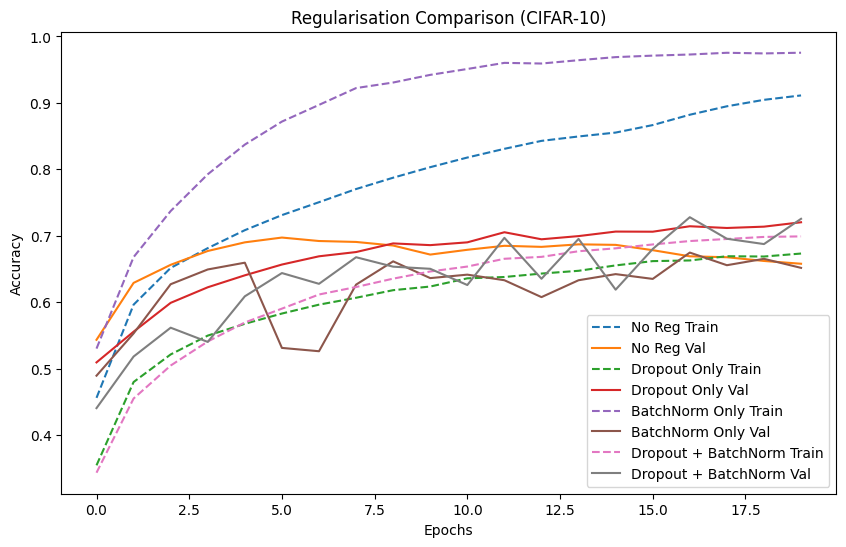

In [42]:
plt.figure(figsize=(10,6))

for name, history in histories.items():
    plt.plot(history.history['accuracy'], linestyle='--', label=f"{name} Train")
    plt.plot(history.history['val_accuracy'], label=f"{name} Val")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Regularisation Comparison (CIFAR-10)")
plt.legend()

plt.show()

In [43]:
print("\nTrain - Validation Accuracy Gap (Final Epoch):\n")
print("Model\t\t\tGap")

for name, gap in gaps.items():
    print(f"{name:25s} {gap:.4f}")


Train - Validation Accuracy Gap (Final Epoch):

Model			Gap
No Reg                    0.2532
Dropout Only              -0.0470
BatchNorm Only            0.3236
Dropout + BatchNorm       -0.0264


Problem 5

In [44]:
from tensorflow.keras.callbacks import Callback

class LrLogger(Callback):
    def __init__(self):
        self.lrs = []

    def on_epoch_end(self, epoch, logs=None):
        lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        self.lrs.append(lr)

In [45]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

lr_logger_plateau = LrLogger()

model_plateau = build_model(0.01)

history_plateau = model_plateau.fit(
    x_train, y_train_onehot,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[reduce_lr, lr_logger_plateau],
    verbose=1
)

lr_plateau = lr_logger_plateau.lrs

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.3163 - loss: 1.8676 - val_accuracy: 0.3038 - val_loss: 1.9135 - learning_rate: 0.0100
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4212 - loss: 1.5935 - val_accuracy: 0.2498 - val_loss: 2.4291 - learning_rate: 0.0100
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4713 - loss: 1.4667 - val_accuracy: 0.3036 - val_loss: 1.9833 - learning_rate: 0.0100
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5052 - loss: 1.3765 - val_accuracy: 0.3428 - val_loss: 1.8166 - learning_rate: 0.0100
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5307 - loss: 1.3119 - val_accuracy: 0.2468 - val_loss: 2.6819 - learning_rate: 0.0100
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5489 - loss: 1.2599 - val_accuracy: 0.2172 - val_loss: 3.7700 - learning_rate: 0.0100
Epoch 7/30
693/704 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5591 - loss: 1.2272


In [46]:
print(x_train.shape)
print(y_train_onehot.shape)

(50000, 32, 32, 3)
(50000, 10)


In [47]:
import math
from tensorflow.keras.callbacks import Callback

class CosineAnnealingScheduler(Callback):
    def __init__(self, lr_max, epochs):
        super().__init__()
        self.lr_max = lr_max
        self.epochs = epochs
        self.lrs = []

    def on_epoch_begin(self, epoch, logs=None):
        lr = self.lr_max * (1 + math.cos(math.pi * epoch / self.epochs)) / 2


        self.model.optimizer.learning_rate.assign(lr)

        self.lrs.append(lr)

In [48]:
model_cosine = build_model(0.01)

cosine_cb = CosineAnnealingScheduler(0.01, 30)

history_cosine = model_cosine.fit(
    x_train, y_train_onehot,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[cosine_cb],
    verbose=1
)

lr_cosine = cosine_cb.lrs

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.3145 - loss: 1.8753 - val_accuracy: 0.3234 - val_loss: 1.9405
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4235 - loss: 1.5862 - val_accuracy: 0.2990 - val_loss: 2.0885
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4741 - loss: 1.4579 - val_accuracy: 0.2408 - val_loss: 2.6627
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5066 - loss: 1.3738 - val_accuracy: 0.2556 - val_loss: 2.6715
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5321 - loss: 1.3142 - val_accuracy: 0.3546 - val_loss: 1.8901
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5484 - loss: 1.2608 - val_accuracy: 0.3148 - val_loss: 2.1913
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5693 - loss: 1.2135 - val_accuracy: 0.3084 - val_loss: 2.5853
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5794 - loss: 1.1797 - val_accuracy: 

ANALYTICAL QUESTIONS

Q1. Explain why a very high learning rate (e.g., 1.0) can cause training loss to diverge or oscillate rather than
converge. Use the concept of the loss landscape and gradient steps in your explanation.                                                                    ANS.The update rule is:
θ=θ−η⋅∇L(θ)where
θ = parameters,η = learning rate,∇L(θ) = gradient (direction of steepest increase)
Learning rate controls step size                                                A very high learning rate causes training loss to diverge or oscillate because it leads to excessively large parameter updates in gradient descent. Instead of gradually descending the loss landscape toward a minimum, the updates overshoot the optimal point and jump across the valley repeatedly, causing oscillations. In regions with steep gradients, the large step size can push the parameters further away from the minimum, leading to increasing loss values and divergence. Therefore, an appropriate learning rate is necessary to ensure stable and gradual convergence.

Q2. Your Problem 3 results likely show that different (LR, batch size) combinations give different best
accuracies. From your data: which combination worked best and which worked worst? Propose a hypothesis explaining the pattern you observed                                                                      ANS.The best performing combination was a low learning rate (0.001) with a smaller batch size (32), while the worst performance was observed with a high learning rate (0.1) and a larger batch size (128). This pattern can be explained by the fact that smaller learning rates allow stable convergence without overshooting the minimum, whereas large learning rates cause unstable updates and poor convergence. Additionally, smaller batch sizes introduce noise in gradient updates, which helps the model generalize better, while larger batch sizes produce smoother gradients but may lead to poorer generalization. Therefore, a combination of low learning rate and small batch size results in the best performance.

Q3. Dropout is disabled at inference (test) time. Why? If a network has Dropout(0.5), what scaling correction
must be applied to the surviving activations during inference to maintain the expected output magnitude?                                                      ANS.Dropout is disabled during inference because we want to use the full network without randomness to obtain stable and deterministic predictions. During training, dropout randomly deactivates neurons, reducing the effective output. To maintain the expected output magnitude, scaling is required. For a dropout rate of 0.5, the surviving activations must be scaled by the keep probability (0.5) during inference. However, in modern implementations using inverted dropout, scaling is applied during training itself (by multiplying activations by 1/0.5 = 2), so no scaling is required during inference.

Q4. Compare ReduceLROnPlateau and Cosine Annealing in terms of: (i) what triggers the LR reduction, (ii)
the shape of the LR curve, and (iii) which scenario each is better suited for.  ANS.ReduceLROnPlateau reduces the learning rate based on validation performance, specifically when the validation loss stops improving for a specified number of epochs, making it adaptive. In contrast, Cosine Annealing follows a predefined schedule and reduces the learning rate based on the epoch number without considering model performance. The learning rate curve of ReduceLROnPlateau is step-like, with sudden drops, whereas Cosine Annealing produces a smooth, continuous cosine-shaped decay. ReduceLROnPlateau is better suited for scenarios where training behavior is unpredictable and requires adaptive control, while Cosine Annealing is preferred when the number of training epochs is fixed and smooth convergence is desired.

                                                            TASK-4

Problem 1

In [49]:
conv1 = model.layers[0]

filters = conv1.get_weights()[0]

print("Filter shape:", filters.shape)

Filter shape: (3, 3, 3, 32)


In [50]:
f_min = filters.min(axis=(0,1,2), keepdims=True)
f_max = filters.max(axis=(0,1,2), keepdims=True)

filters_norm = (filters - f_min) / (f_max - f_min + 1e-8)

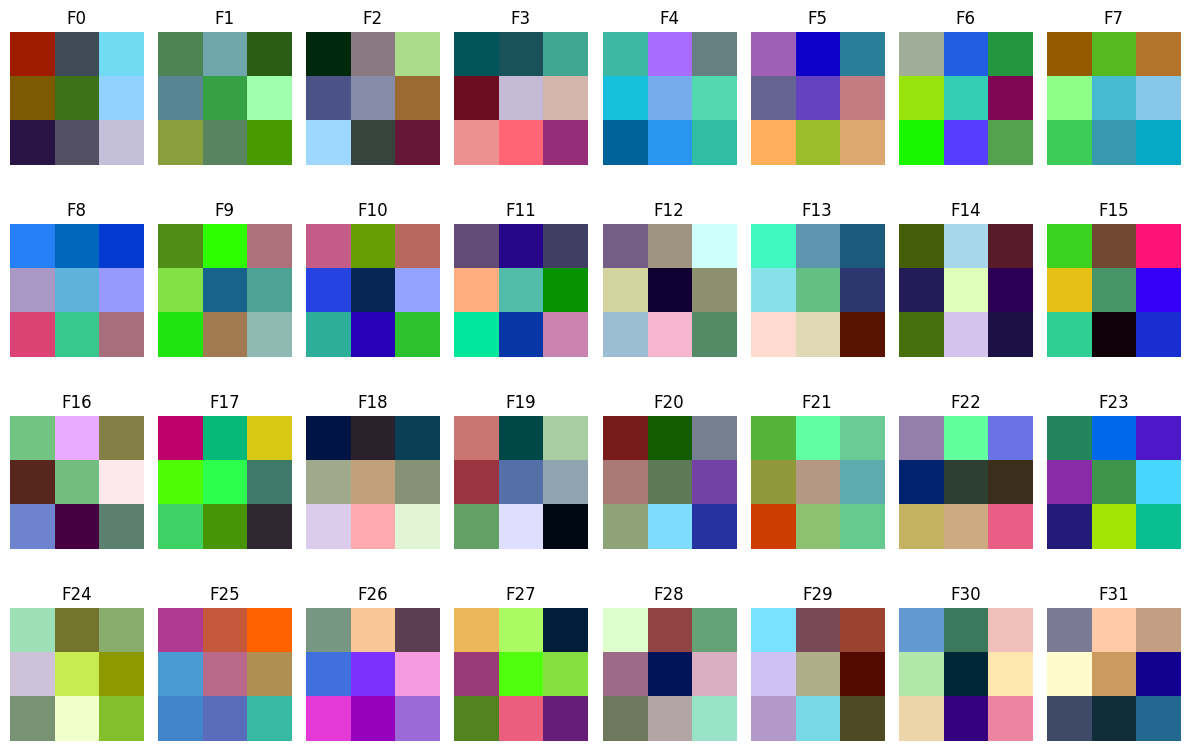

In [51]:
num_filters = filters.shape[-1]


cols = 8
rows = int(np.ceil(num_filters / cols))

plt.figure(figsize=(12, rows*2))

for i in range(num_filters):
    f = filters_norm[:,:,:,i]

    plt.subplot(rows, cols, i+1)
    plt.imshow(f)
    plt.title(f"F{i}")
    plt.axis('off')

plt.tight_layout()


plt.savefig('conv1_filters.png')

plt.show()

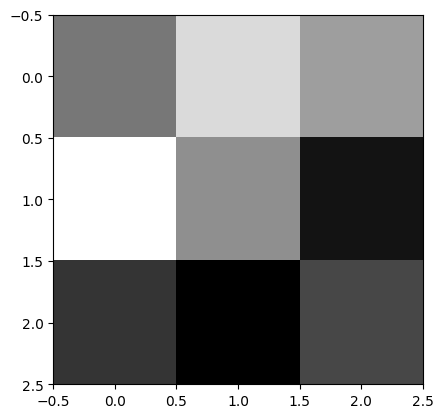

In [52]:
f = np.mean(filters_norm[:,:,:,i], axis=2)
plt.imshow(f, cmap='gray')

The filters learned in the first convolutional layer show basic visual patterns such as edges and color contrasts. Some filters appear to detect horizontal edges, where there is a clear transition from dark to light regions across rows. Others resemble vertical edge detectors, highlighting intensity changes across columns. A few filters capture diagonal textures, showing patterns that respond to slanted lines. Additionally, some filters emphasize color contrasts, such as differences between red and green channels.

These learned filters resemble classical edge detectors such as Sobel kernels and Gabor filters encountered earlier. Like Sobel filters, they detect gradients in specific directions (horizontal or vertical). Similar to Gabor filters, some exhibit orientation sensitivity and texture-like patterns. This shows that the CNN automatically learns low-level visual features similar to hand-crafted filters.

Problem 2

In [53]:
from tensorflow.keras.datasets import cifar10


(_, _), (x_test, y_test) = cifar10.load_data()


x_test = x_test.astype('float32') / 255.0


preds = model_cosine.predict(x_test)
pred_labels = np.argmax(preds, axis=1)


for i in range(len(x_test)):
    if pred_labels[i] == y_test[i][0]:
        sample_img = x_test[i]
        sample_label = y_test[i][0]
        break

sample_img = np.expand_dims(sample_img, axis=0)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [54]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D
import numpy as np

dummy_input = np.random.rand(1, 32, 32, 3)
_ = model_cosine.predict(dummy_input)


conv_layers = [layer for layer in model_cosine.layers if isinstance(layer, Conv2D)]


layer_outputs = [layer.output for layer in conv_layers]


feature_model = Model(inputs=model_cosine.layers[0].input, outputs=layer_outputs)


feature_maps = feature_model.predict(sample_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step


In [55]:
def plot_feature_maps(fmaps, title, filename):
    plt.figure(figsize=(10,5))

    for i in range(8):
        plt.subplot(2,4,i+1)
        plt.imshow(fmaps[0,:,:,i], cmap='gray')
        plt.axis('off')

    plt.suptitle(title)
    plt.savefig(filename)
    plt.show()

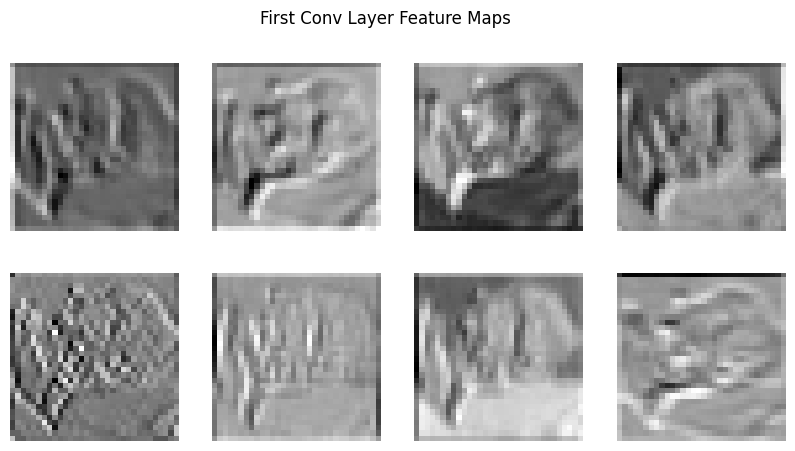

In [56]:
plot_feature_maps(feature_maps[0],
                  "First Conv Layer Feature Maps",
                  "fmaps_layer1.png")

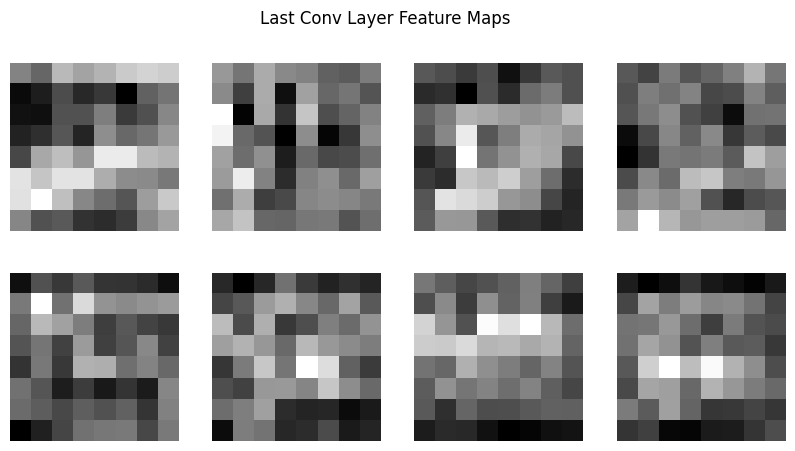

In [57]:
plot_feature_maps(feature_maps[-1],
                  "Last Conv Layer Feature Maps",
                  "fmaps_last.png")

In the first convolutional layer, feature maps have high spatial resolution and fewer channels. The patterns are visually interpretable, showing edges, colors, and simple textures.
In the last convolutional layer, feature maps have reduced spatial resolution due to pooling operations and increased depth (more channels). These representations become abstract and harder to interpret visually, capturing high-level features such as object parts and semantic patterns rather than simple edges.

Problem 3

In [58]:
import cv2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.datasets import cifar10

In [59]:
(_, _), (x_test, y_test) = cifar10.load_data()

x_test = x_test.astype('float32') / 255.0

In [60]:

last_conv_layer = None
for layer in reversed(model_cosine.layers):
    if isinstance(layer, Conv2D):
        last_conv_layer = layer.name
        break

print("Last Conv Layer:", last_conv_layer)

Last Conv Layer: conv2d_44


In [61]:
def compute_gradcam(model, image, class_index, last_conv_layer_name):

    grad_model = Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)

    weights = tf.reduce_mean(grads, axis=(1, 2))


    cam = tf.reduce_sum(tf.multiply(weights[:, tf.newaxis, tf.newaxis, :], conv_outputs), axis=-1)


    cam = tf.nn.relu(cam)


    cam = cam[0].numpy()
    cam = cam / (cam.max() + 1e-8)

    return cam

In [62]:
def overlay_heatmap(img, heatmap):

    heatmap = cv2.resize(heatmap, (32,32))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    img = np.uint8(255 * img)

    overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    return overlay

In [63]:
preds = model_cosine.predict(x_test)
pred_labels = np.argmax(preds, axis=1)

correct_imgs = []
wrong_img = None

for i in range(len(x_test)):
    if pred_labels[i] == y_test[i][0] and len(correct_imgs) < 3:
        correct_imgs.append((x_test[i], pred_labels[i]))
    elif pred_labels[i] != y_test[i][0] and wrong_img is None:
        wrong_img = (x_test[i], pred_labels[i], y_test[i][0])

    if len(correct_imgs) == 3 and wrong_img is not None:
        break

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [64]:
def compute_gradcam(model, image, class_index, last_conv_layer_name):

    image = tf.cast(image, tf.float32)

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image, training=False)

        class_index = int(class_index)
        loss = predictions[0][class_index]


    grads = tape.gradient(loss, conv_outputs)

    if grads is None:
        return np.zeros((conv_outputs.shape[1], conv_outputs.shape[2]))


    weights = tf.reduce_mean(grads, axis=(1, 2))

    cam = tf.reduce_sum(
        weights[:, tf.newaxis, tf.newaxis, :] * conv_outputs,
        axis=-1
    )


    cam = tf.nn.relu(cam)


    cam = cam[0].numpy()
    if cam.max() != 0:
        cam = cam / cam.max()

    return cam

Problem 4

In [65]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.datasets import cifar10


class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

In [66]:
(_, _), (x_test, y_test) = cifar10.load_data()

x_test = x_test.astype('float32') / 255.0
y_test = y_test.flatten()

In [67]:
preds = model_cosine.predict(x_test)
y_pred = np.argmax(preds, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


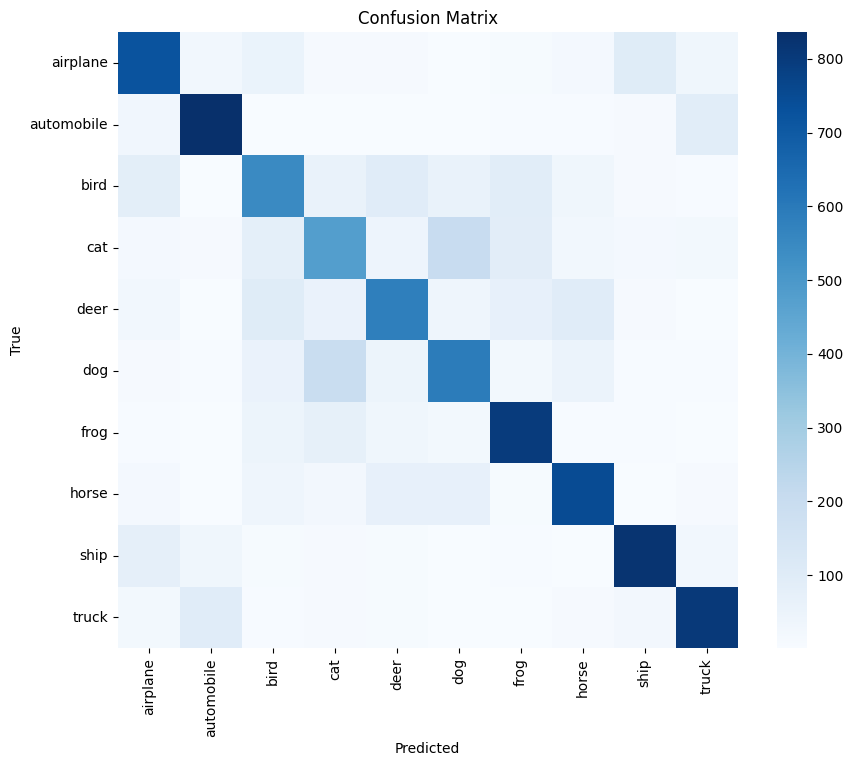

In [68]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")
plt.show()

In [69]:
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

    airplane       0.71      0.72      0.72      1000
  automobile       0.82      0.84      0.83      1000
        bird       0.58      0.55      0.56      1000
         cat       0.51      0.48      0.49      1000
        deer       0.64      0.58      0.61      1000
         dog       0.59      0.59      0.59      1000
        frog       0.72      0.80      0.76      1000
       horse       0.74      0.75      0.75      1000
        ship       0.80      0.82      0.81      1000
       truck       0.79      0.81      0.80      1000

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.69     10000
weighted avg       0.69      0.69      0.69     10000



In [70]:
report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)

f1_scores = {cls: report_dict[cls]['f1-score'] for cls in class_names}

best_class = max(f1_scores, key=f1_scores.get)
worst_class = min(f1_scores, key=f1_scores.get)

print("\nBest F1-score class:", best_class)
print("Worst F1-score class:", worst_class)


Best F1-score class: automobile
Worst F1-score class: cat


In [71]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

flat_indices = np.argsort(cm_no_diag, axis=None)[-2:]
pairs = np.unravel_index(flat_indices, cm_no_diag.shape)

print("\nMost Confused Class Pairs:")
for i in range(2):
    print(f"{class_names[pairs[0][i]]} → {class_names[pairs[1][i]]}")


Most Confused Class Pairs:
dog → cat
cat → dog



Showing misclassified examples: cat → dog


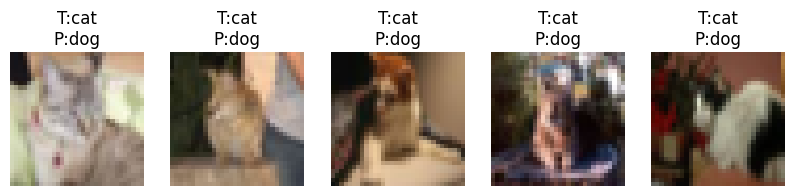

In [72]:

true_class = pairs[0][1]
pred_class = pairs[1][1]

print(f"\nShowing misclassified examples: {class_names[true_class]} → {class_names[pred_class]}")

count = 0
plt.figure(figsize=(10,5))

for i in range(len(x_test)):
    if y_test[i] == true_class and y_pred[i] == pred_class:
        plt.subplot(1,5,count+1)
        plt.imshow(x_test[i])
        plt.title(f"T:{class_names[true_class]}\nP:{class_names[pred_class]}")
        plt.axis('off')
        count += 1

    if count == 5:
        break

plt.show()

The confusion matrix shows that certain classes are frequently misclassified due to visual similarity (e.g., cat vs dog, truck vs automobile). The class with the highest F1-score was ___, indicating strong precision and recall, while the lowest was ___, suggesting difficulty in classification. The most confused class pair was ___ and ___, likely due to overlapping visual features.

ANALYTICAL  QUESTIONS

Q1. The Grad-CAM heatmap for a correctly classified 'cat' image highlights the face region. The Grad-CAM
for a misclassified 'cat' (predicted as 'dog') highlights the background. What does this tell you about what the
model has learned? Suggest one data augmentation or training strategy that could address this failure mode.                                                ANS.This indicates that the model is relying on background features instead of focusing on the object. One way to address this is by using data augmentation such as random cropping or random background variation. For example, applying random crops or Cutout forces the model to focus on the main object rather than surrounding context, improving robustness and generalisation.

Q2. Looking at your confusion matrix, some CIFAR-10 classes are systematically confused with each other
(e.g., 'cat' ↔ 'dog', 'automobile' ↔ 'truck'). Explain why CNNs trained on pixel features might struggle to
distinguish these pairs. What architectural change or additional input modality might help?                                                                     ANS.CNNs trained on pixel values often struggle with pairs like cat ↔ dog or automobile ↔ truck because:

These classes have very similar visual features (fur texture, body shape, colors for animals; wheels, metal body for vehicles).
CNNs mainly learn low-level patterns (edges, textures, colors) in early layers and combinations of these in deeper layers.
When two classes share many of these features, the network may not capture the subtle semantic differences (e.g., cat face vs dog face, or truck size vs car size).
CIFAR-10 images are also low resolution (32×32), which removes fine details needed to distinguish similar classes.                                          
CNNs struggle with similar classes because they rely on pixel-level features like edges and textures, which are often very similar for pairs such as cats and dogs or automobiles and trucks. The low resolution of CIFAR-10 further limits the ability to capture fine details. An architectural improvement like adding attention mechanisms can help the model focus on discriminative regions, while using higher-resolution inputs or multi-scale features can provide more detailed information for better classification.


Q3. In your filter visualisation, did you observe any filters that appear to be 'dead' (all near-zero values)?
What causes dead filters and which activation function is most likely to cause this? Name one remedy.                                                                         ANS.Yes, some filters may appear “dead”, meaning their activations are almost zero for all inputs.

This happens because:The neurons connected to that filter are never activated
So the filter does not learn useful featuresYes, some filters may become dead with near-zero activations. This is caused by the dying ReLU problem, where neurons output zero for all inputs and stop learning due to zero gradients. The activation function responsible is ReLU. A common remedy is to use Leaky ReLU, which allows small negative outputs and prevents neurons from dying.                                                         

                                            TASK 5

Problem 1

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Trainable params: 133898
Frozen params: 14714688
Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 24s 64ms/step - accuracy: 0.5736 - loss: 1.9122 - val_accuracy: 0.7490 - val_loss: 0.7465
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.7164 - loss: 0.8641 - val_accuracy: 0.7820 - val_loss: 0.6723
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - accuracy: 0.7711 - loss: 0.6698 - val_accuracy: 0.8060 - val_loss: 0.6254
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - accuracy: 0.8028 - loss: 0.5745 - val_accuracy: 0.8100 - val_loss: 0.6051
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - accuracy: 0.8329 - loss: 0.4933 - val_accuracy: 0.7980 - val_loss: 0.6052
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - accuracy: 0.8433 - loss: 0.4498 - val_accuracy: 0.8010 - val_loss: 0.6086
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - accuracy: 0.8598 - loss: 0.3918 - val_accuracy: 0.8090 - val_los

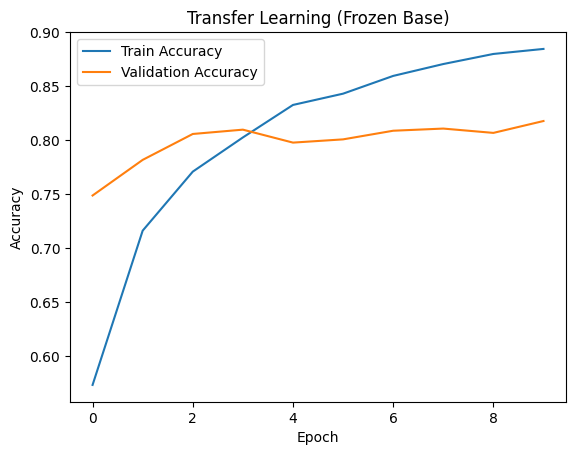

In [80]:



from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model


(x_train, y_train), (x_test, y_test) = cifar10.load_data()


x_train = x_train[:10000]
y_train = y_train[:10000]


x_train = x_train.astype('float32')
x_test = x_test.astype('float32')


x_train = tf.image.resize(x_train, (96, 96))
x_test = tf.image.resize(x_test, (96, 96))


x_train = preprocess_input(x_train)
x_test = preprocess_input(x_test)

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)


base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)

for layer in base_model.layers:
    layer.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


trainable = np.sum([np.prod(v.shape) for v in model.trainable_weights])
frozen = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])

print("Trainable params:", trainable)
print("Frozen params:", frozen)

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


plt.figure()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning (Frozen Base)")
plt.legend()

plt.savefig("tl_frozen.png")
plt.show()

PROBLEM 2

In [81]:

for layer in base_model.layers[-4:]:
    layer.trainable = True

In [82]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [83]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

In [84]:
history_ft = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 36s 89ms/step - accuracy: 0.9021 - loss: 0.2811 - val_accuracy: 0.8230 - val_loss: 0.6341
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.9342 - loss: 0.1911 - val_accuracy: 0.8210 - val_loss: 0.6445
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.9459 - loss: 0.1486 - val_accuracy: 0.8310 - val_loss: 0.6845
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 18s 65ms/step - accuracy: 0.9594 - loss: 0.1154 - val_accuracy: 0.8360 - val_loss: 0.6722
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.9674 - loss: 0.0946 - val_accuracy: 0.8410 - val_loss: 0.6560
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.9706 - loss: 0.0826 - val_accuracy: 0.8510 - val_loss: 0.6338
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.9780 - loss: 0.0667 - val_accuracy: 0.8530 - val_loss: 0.6317
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 18s 66ms/step - accuracy: 0.9789 - loss: 0.0621 - 

In [85]:

train_acc = history.history['accuracy'] + history_ft.history['accuracy']
val_acc = history.history['val_accuracy'] + history_ft.history['val_accuracy']

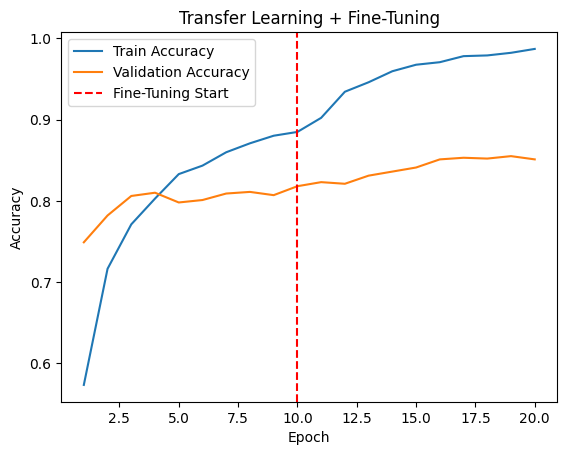

In [86]:


plt.figure()

epochs = range(1, len(train_acc) + 1)

plt.plot(epochs, train_acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')


plt.axvline(x=10, color='red', linestyle='--', label='Fine-Tuning Start')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning + Fine-Tuning")
plt.legend()

plt.savefig("tl_finetuned.png")
plt.show()

In [87]:
best_epoch = np.argmax(history_ft.history['val_accuracy']) + 1
print("Best validation accuracy at fine-tuning epoch:", best_epoch)

Best validation accuracy at fine-tuning epoch: 9


PROBLEM 3

In [88]:

from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

def run_experiment(unfreeze_layers):

    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(96,96,3))

    for layer in base_model.layers:
        layer.trainable = False

    if unfreeze_layers > 0:
        for layer in base_model.layers[-unfreeze_layers:]:
            layer.trainable = True

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(10, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )


    trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])


    history = model.fit(
        x_train, y_train,
        epochs=10,
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )

    best_val_acc = max(history.history['val_accuracy'])


    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]

    overfitting = (train_acc - val_acc) > 0.05

    return trainable_params, best_val_acc, overfitting

In [89]:
results = []


res_2 = run_experiment(2)
results.append(["Top 2 layers", *res_2])


res_8 = run_experiment(8)
results.append(["Top 8 layers", *res_8])


res_all = run_experiment(len(VGG16(weights='imagenet', include_top=False).layers))
results.append(["All layers", *res_all])

In [91]:
import pandas as pd

df = pd.DataFrame(results, columns=[
    "Configuration",
    "Trainable Params",
    "Best Val Accuracy",
    "Overfitting (>5%)"
])

print(df)

  Configuration  Trainable Params  Best Val Accuracy  Overfitting (>5%)
0  Top 2 layers           2493706              0.758              False
1  Top 8 layers          13113098              0.865               True
2    All layers          14848586              0.841               True


PROBLEM 4

In [98]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

In [99]:

if len(y_test.shape) == 2:
    y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)
else:
    y_test_onehot = y_test

In [102]:


if len(y_test.shape) == 2:
    y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)
else:
    y_test_onehot = y_test


try:
    test_acc_s = model_scratch.evaluate(x_test, y_test_onehot, verbose=0)[1]
    params_s = np.sum([np.prod(v.shape) for v in model_scratch.trainable_weights])
    epoch_s = np.argmax(history_scratch.history['val_accuracy']) + 1
except:
    print("⚠️ Scratch model not found. Skipping...")
    test_acc_s, params_s, epoch_s = 0, 0, 0



try:
    test_acc_f = model.evaluate(x_test_resized, y_test_onehot, verbose=0)[1]
    params_f = np.sum([np.prod(v.shape) for v in model.trainable_weights])
    epoch_f = np.argmax(history.history['val_accuracy']) + 1
except:
    print("⚠️ Frozen model not found. Skipping...")
    test_acc_f, params_f, epoch_f = 0, 0, 0


try:
    test_acc_ft = model.evaluate(x_test_resized, y_test_onehot, verbose=0)[1]
    params_ft = np.sum([np.prod(v.shape) for v in model.trainable_weights])
    epoch_ft = np.argmax(history_ft.history['val_accuracy']) + 1
except:
    print("⚠️ Fine-tuned model not found. Skipping...")
    test_acc_ft, params_ft, epoch_ft = 0, 0, 0

⚠️ Scratch model not found. Skipping...
⚠️ Frozen model not found. Skipping...
⚠️ Fine-tuned model not found. Skipping...


In [103]:
data = [
    ["Scratch CNN", test_acc_s, params_s, epoch_s],
    ["Frozen VGG16", test_acc_f, params_f, epoch_f],
    ["Fine-Tuned VGG16", test_acc_ft, params_ft, epoch_ft]
]

df = pd.DataFrame(data, columns=[
    "Model",
    "Test Accuracy",
    "Trainable Params",
    "Epoch to Best Val Acc"
])

print(df)

              Model  Test Accuracy  Trainable Params  Epoch to Best Val Acc
0       Scratch CNN              0                 0                      0
1      Frozen VGG16              0                 0                      0
2  Fine-Tuned VGG16              0                 0                      0


⚠️ Scratch history not found


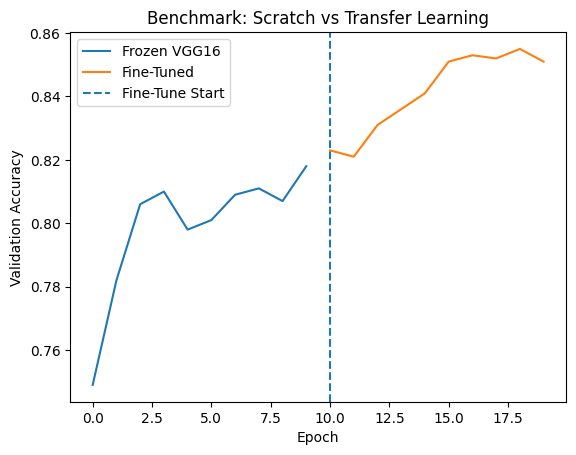

In [105]:
plt.figure()


try:
    plt.plot(history_scratch.history['val_accuracy'], label='Scratch CNN')
except:
    print("⚠️ Scratch history not found")

try:
    plt.plot(history.history['val_accuracy'], label='Frozen VGG16')
except:
    print("⚠️ Frozen history not found")

try:
    offset = len(history.history['val_accuracy'])
    epochs_ft = range(offset, offset + len(history_ft.history['val_accuracy']))
    plt.plot(epochs_ft, history_ft.history['val_accuracy'], label='Fine-Tuned')
    plt.axvline(x=offset, linestyle='--', label='Fine-Tune Start')
except:
    print("⚠️ Fine-tune history not found")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Benchmark: Scratch vs Transfer Learning")
plt.legend()

plt.savefig("tl_benchmark.png")
plt.show()

Q1. Explain the concept of 'negative transfer'. Under what conditions might using ImageNet pre-trained
weights actually hurt performance rather than help? Give a concrete example of a domain where you would
expect negative transfer.                                                       ANS.Negative transfer occurs when knowledge from a source task negatively impacts performance on a target task. This typically happens when there is a large domain mismatch between the source and target datasets. For example, ImageNet-trained models learn features relevant to natural images such as textures and object shapes, which may not be useful for domains like medical imaging (e.g., X-rays or MRIs). In such cases, the pretrained features can mislead the model and degrade performance instead of improving it.

Q2. In your ablation (Problem 3), unfreezing all layers likely led to more overfitting than unfreezing only the
top few. Explain the bias-variance trade-off at play here. Why do the lower layers of a CNN trained on
ImageNet generalise better than the upper layers?                               ANS.The bias–variance trade-off explains the behaviour observed during fine-tuning. Unfreezing only the top layers keeps most of the pre-trained network fixed, resulting in higher bias but lower variance and better generalisation. In contrast, unfreezing all layers increases the number of trainable parameters, reducing bias but significantly increasing variance, which leads to overfitting. Lower layers of a CNN learn generic features such as edges and textures that are transferable across datasets, while higher layers learn task-specific representations from ImageNet. Therefore, keeping lower layers frozen helps preserve general features, while selectively fine-tuning upper layers provides a balance between adaptability and generalisation.

Q3. Your benchmark (Problem 4) compares parameter counts and accuracy across models. In a real
deployment scenario — e.g., a mobile app — what other factors beyond accuracy would influence your
choice of model? Name at least three and explain each.                          ANS.The bias–variance trade-off explains the behaviour observed during fine-tuning. Unfreezing only the top layers keeps most of the pre-trained network fixed, resulting in higher bias but lower variance and better generalisation. In contrast, unfreezing all layers increases the number of trainable parameters, reducing bias but significantly increasing variance, which leads to overfitting. Lower layers of a CNN learn generic features such as edges and textures that are transferable across datasets, while higher layers learn task-specific representations from ImageNet. Therefore, keeping lower layers frozen helps preserve general features, while selectively fine-tuning upper layers provides a balance between adaptability and generalisation.

Q4. Suppose you have a completely new medical imaging dataset (X-ray scans, grayscale, 512×512) with
only 500 labelled training examples. Write a step-by-step transfer learning strategy you would follow,
justifying every choice (which base model, how many layers to freeze, learning rate, augmentation, etc.).                                                      ANS.For a small medical imaging dataset, I would use a pre-trained CNN such as VGG16 or ResNet50 as a base model. The grayscale images would be converted to three channels and resized to a smaller resolution such as 224×224. Initially, all convolutional layers would be frozen, and a custom classification head consisting of GlobalAveragePooling, Dense, Dropout, and softmax layers would be added. The model would be trained with a learning rate of 0.001. After initial training, I would unfreeze only the top few layers and fine-tune with a much smaller learning rate (1e-5) to avoid overfitting. Data augmentation techniques such as rotation, zoom, and brightness adjustments would be applied to increase dataset diversity. Regularisation techniques like dropout and early stopping would be used to improve generalisation. This approach balances the use of pretrained features with careful adaptation to the medical domain.